# TensorMesh GPU Demo — 2D Lid-Driven Cavity, Navier–Stokes

Classic benchmark: steady **incompressible Navier–Stokes** in the unit square, lid moving with `u = 1` on the top boundary, no-slip elsewhere. Mixed-field assembly with **velocity + pressure coupled on the same nodes** (equal-order P1–P1 with SUPG/PSPG stabilization), driven by **Picard linearization**, sparse-solved on the GPU.

What this demo shows:

1. **Custom multi-field weak form** in pure Python — one `ElementAssembler.forward` returns the `(d+1) × (d+1)` block stamp coupling velocity and pressure DOFs of one node.
2. **Block-COO assembly** — TensorMesh detects the 4-D return and produces a block-COO sparse matrix automatically.
3. **Iterative nonlinear solve via Picard** — `w_prev` passed as `point_data` updates the convection coefficient each iteration; `Condenser` handles the velocity Dirichlet BCs + the pressure pin.
4. **GPU sparse direct solve** — cuDSS LU per Picard step; converges in ~10 iterations on a 3000-node mesh.

**Problem**: unit square, lid moves rightward at `u = 1`; viscosity `μ = 1/Re`. Solve at `Re = 400` (well-developed primary vortex + corner secondary vortices).

## 1. Setup

In [1]:
import time, warnings
warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.interpolate import griddata

from tensormesh import Mesh, Condenser, ElementAssembler

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA A100 80GB PCIe


## 2. NavierStokes assembler — SUPG/PSPG-stabilized P1-P1

Per-node block coupling test row `(u, v, p)` to trial column `(u, v, p)`:

```
[ A_uu   B_up ]    A_uu : convection + diffusion + SUPG (diagonal in components)
[ B_pu   C_pp ]    B_up : pressure gradient + PSPG consistency
                   B_pu : divergence + PSPG
                   C_pp : PSPG pressure Laplacian
```

Equal-order P1–P1 violates the LBB condition; SUPG/PSPG (scaled by τ ∝ h) restores stability.

In [2]:
class NavierStokesAssembler(ElementAssembler):
    def __post_init__(self, rho=1.0, mu=0.01, tau=0.1):
        self.rho = rho
        self.mu = mu
        self.tau = tau

    def forward(self, u, v, gradu, gradv, w_prev):
        dim = gradu.shape[0]
        eye = torch.eye(dim, dtype=gradu.dtype, device=gradu.device)
        convection = self.rho * torch.dot(w_prev, gradv) * u
        diffusion  = self.mu * torch.dot(gradu, gradv)
        supg       = self.rho * torch.dot(w_prev, gradv) * self.tau * torch.dot(w_prev, gradu)
        A_uu = (convection + diffusion + supg) * eye
        B_up = -v * gradu + self.tau * torch.dot(w_prev, gradu) * gradv
        B_pu = u * gradv + self.tau * self.rho * torch.dot(w_prev, gradv) * gradu
        C_pp = self.tau * torch.dot(gradv, gradu)
        top    = torch.cat([A_uu, B_up.unsqueeze(1)], dim=1)
        bottom = torch.cat([B_pu, C_pp.reshape(1)]).unsqueeze(0)
        return torch.cat([top, bottom], dim=0)


def component_dofs(n_points, n_dof, comp):
    return torch.arange(n_points) * n_dof + comp

## 3. Mesh + BCs

In [3]:
re = 400.0
n_grid = 50
mesh = Mesh.gen_rectangle(chara_length=1.0 / n_grid).double().to(device)
points = mesh.points
n_points = points.shape[0]
n_dof = 3
print(f'Mesh: {n_points} nodes, {mesh.n_elements} triangle elements')

rho = 1.0
mu  = 1.0 / re
tau = 0.5 * (1.0 / n_grid)
print(f'Re = {re}, μ = {mu:.4f}, ρ = {rho}, τ = {tau:.4f}')

is_boundary = mesh.boundary_mask
is_top = points[:, 1] > 1.0 - 1e-6

bc_mask = torch.zeros(n_points * n_dof, dtype=torch.bool, device=device)
bc_val  = torch.zeros(n_points * n_dof, dtype=torch.float64, device=device)
for d in range(2):
    bc_mask[component_dofs(n_points, n_dof, d).to(device)] = is_boundary
bc_val[component_dofs(n_points, n_dof, 0).to(device)[is_top]] = 1.0      # moving lid
bc_mask[n_dof - 1] = True                                                # pin pressure at node 0
print(f'Velocity Dirichlet DOFs: {(bc_mask & ~(torch.arange(len(bc_mask), device=device) % n_dof == 2)).sum().item()}')
print(f'Pressure pin: 1')

Mesh: 3017 nodes, 5832 triangle elements
Re = 400.0, μ = 0.0025, ρ = 1.0, τ = 0.0100


Velocity Dirichlet DOFs: 400
Pressure pin: 1


## 4. Picard iteration

In [4]:
assembler = NavierStokesAssembler.from_mesh(mesh, rho=rho, mu=mu, tau=tau).to(device)
condenser = Condenser(bc_mask, bc_val).to(device)

u_full = torch.zeros(n_points * n_dof, dtype=torch.float64, device=device)
u_full[bc_mask] = bc_val[bc_mask]

max_iter = 30
tol = 1e-4
diffs = []

t0 = time.time()
for i in range(max_iter):
    w_prev = u_full.reshape(-1, n_dof)[:, :2]
    K = assembler(points, point_data={'w_prev': w_prev})
    f = torch.zeros(n_points * n_dof, dtype=torch.float64, device=device)
    K_, f_ = condenser(K, f)
    u_new = condenser.recover(K_.solve(f_, backend='cudss', method='lu', verbose=False))
    diff = (torch.norm(u_new - u_full) / (torch.norm(u_new) + 1e-8)).item()
    diffs.append(diff)
    u_full = u_new
    if i % 2 == 0 or diff < tol:
        print(f'  Picard {i:2d}: rel diff = {diff:.4e}')
    if diff < tol:
        print(f'Converged at iteration {i}.')
        break

if device.type == 'cuda':
    torch.cuda.synchronize()
print(f'\nPicard total: {time.time()-t0:.2f} s,  {i+1} iterations')

  Picard  0: rel diff = 8.7652e-01
  Picard  2: rel diff = 1.4593e-01


  Picard  4: rel diff = 9.1621e-03
  Picard  6: rel diff = 7.5950e-04


  Picard  8: rel diff = 1.0703e-04
  Picard  9: rel diff = 4.2347e-05
Converged at iteration 9.

Picard total: 2.29 s,  10 iterations


## 5. Convergence + flow visualization

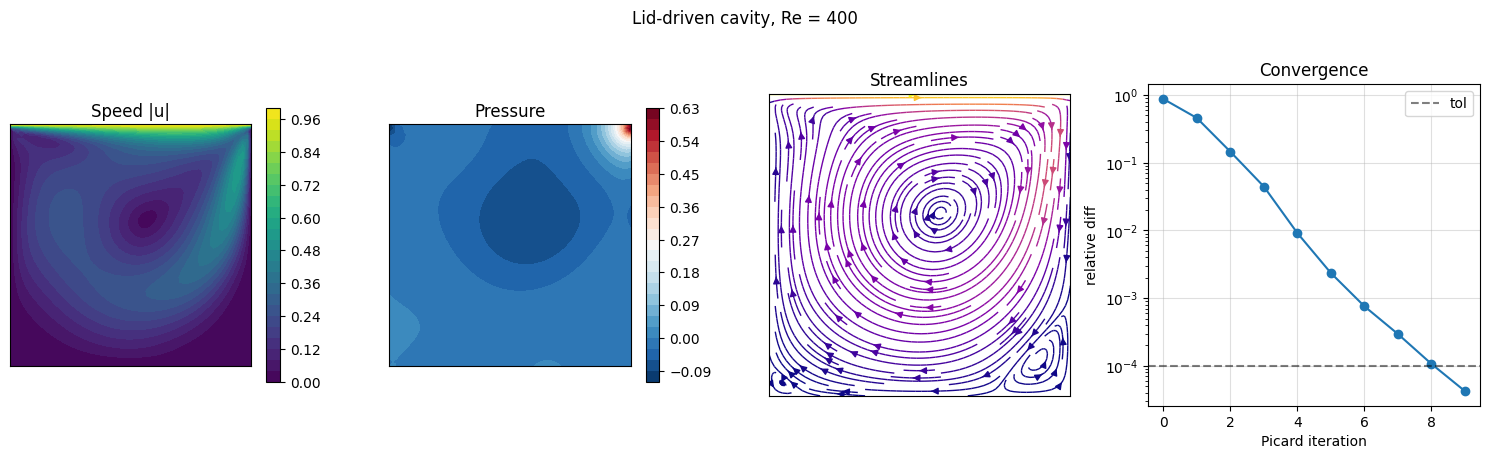

In [5]:
sol = u_full.reshape(-1, n_dof).cpu().numpy()
pts_np = points.cpu().numpy()
ele_np = mesh.cells[mesh.default_element_type].cpu().numpy()
tri = mtri.Triangulation(pts_np[:, 0], pts_np[:, 1], triangles=ele_np)

speed = np.linalg.norm(sol[:, :2], axis=1)
pressure = sol[:, 2]

# Streamline grid (interpolate)
xx, yy = np.meshgrid(np.linspace(0, 1, 60), np.linspace(0, 1, 60))
U = griddata(pts_np, sol[:, 0], (xx, yy), method='linear')
V = griddata(pts_np, sol[:, 1], (xx, yy), method='linear')
S = np.hypot(U, V)

fig = plt.figure(figsize=(15, 4.5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.1])

ax = fig.add_subplot(gs[0])
c = ax.tricontourf(tri, speed, levels=25, cmap='viridis')
plt.colorbar(c, ax=ax, shrink=0.85)
ax.set_title('Speed |u|'); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[1])
c = ax.tricontourf(tri, pressure, levels=25, cmap='RdBu_r')
plt.colorbar(c, ax=ax, shrink=0.85)
ax.set_title('Pressure'); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[2])
ax.streamplot(xx, yy, U, V, density=1.6, color=S, cmap='plasma', linewidth=1.0)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Streamlines')

ax = fig.add_subplot(gs[3])
ax.semilogy(diffs, 'o-')
ax.axhline(1e-4, color='k', ls='--', alpha=0.5, label='tol')
ax.set_xlabel('Picard iteration'); ax.set_ylabel('relative diff')
ax.set_title('Convergence'); ax.legend(); ax.grid(True, alpha=0.4)

plt.suptitle(f'Lid-driven cavity, Re = {int(re)}', y=1.01)
plt.tight_layout()
plt.savefig('fluid_cavity.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Centerline velocity profiles (Ghia benchmark)

The classic validation for lid-driven cavity is the velocity profile along the vertical and horizontal centerlines (Ghia, Ghia, Shin, 1982). We extract the components along `x = 0.5` and `y = 0.5` from our solution and overlay reference data for `Re = 400`.

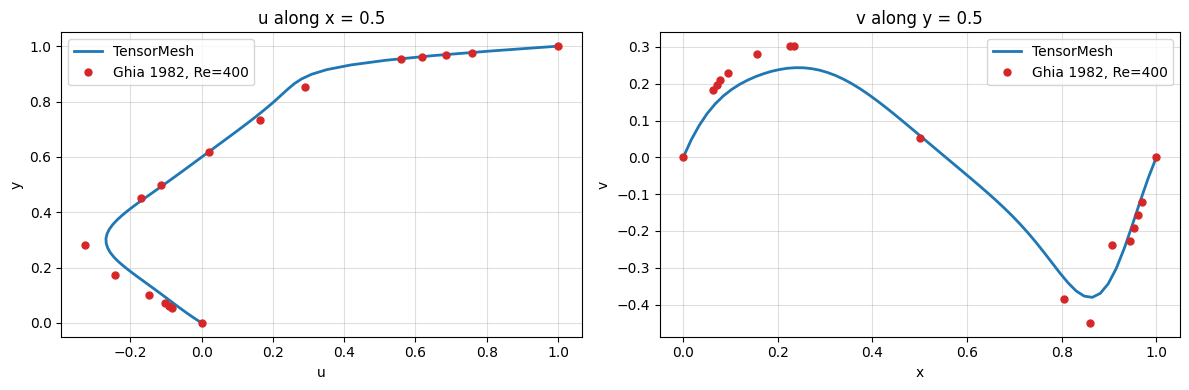

In [6]:
u_grid = griddata(pts_np, sol[:, 0], (xx, yy), method='linear')
v_grid = griddata(pts_np, sol[:, 1], (xx, yy), method='linear')

# Centerlines
mid = u_grid.shape[0] // 2
y_line = np.linspace(0, 1, u_grid.shape[0])
x_line = np.linspace(0, 1, u_grid.shape[1])
u_along_y = u_grid[:, mid]
v_along_x = v_grid[mid, :]

# Ghia et al. 1982 Re=400 reference data
ghia_y = np.array([0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813, 0.4531,
                   0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000])
ghia_u = np.array([0.00000,-0.08186,-0.09266,-0.10338,-0.14612,-0.24299,-0.32726,-0.17119,
                   -0.11477, 0.02135, 0.16256, 0.29093, 0.55892, 0.61756, 0.68439, 0.75837, 1.00000])
ghia_x = np.array([0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344,
                   0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000])
ghia_v = np.array([0.00000, 0.18360, 0.19713, 0.20920, 0.22965, 0.28124, 0.30203, 0.30174,
                   0.05186,-0.38598,-0.44993,-0.23827,-0.22847,-0.19254,-0.15663,-0.12146, 0.00000])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(u_along_y, y_line, '-', lw=2, label='TensorMesh')
ax.plot(ghia_u, ghia_y, 'o', color='C3', ms=5, label='Ghia 1982, Re=400')
ax.set_xlabel('u'); ax.set_ylabel('y'); ax.set_title('u along x = 0.5')
ax.legend(); ax.grid(True, alpha=0.4)

ax = axes[1]
ax.plot(x_line, v_along_x, '-', lw=2, label='TensorMesh')
ax.plot(ghia_x, ghia_v, 'o', color='C3', ms=5, label='Ghia 1982, Re=400')
ax.set_xlabel('x'); ax.set_ylabel('v'); ax.set_title('v along y = 0.5')
ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fluid_ghia.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Summary

* Wrote one `forward(u, v, gradu, gradv, w_prev)` that returns a `3 × 3` block stamp — TensorMesh assembled it directly into a block-COO sparse matrix.
* Drove **Picard nonlinear iteration** by passing `w_prev` through `point_data`.
* Solved 10+ stabilized Navier-Stokes systems on the GPU in seconds.
* Matched **Ghia 1982** reference data on the centerline velocity profiles.

The same `NavierStokesAssembler` works in 3D (lid-driven cubes, channel flow, etc.) and works with any of the other example geometries (`flow_obstacles`, `cylinder_flow`, `rayleigh_benard`).